# Component Forecast

Rate-space blending of the satellite-era quadratic extrapolation (naive forecast)
with the component-level model sum.

**Method:** Blend in rate space so the forecast starts on the observed GMSL
trajectory and transitions smoothly to the component-sum physics:

$$
\dot{H}_\text{forecast}(t) = w(t)\,\dot{H}_\text{quad}(t)
    + \bigl[1 - w(t)\bigr]\,\dot{H}_\text{comp}(t)
$$

where $w(t) = 1 - \sigma\bigl((t - t_c)/\tau_\text{blend}\bigr)$ is a sigmoid
transition centred at $t_c$ with width $\tau_\text{blend}$.  The level forecast
is obtained by integrating from the observed GMSL at the forecast origin.

**Sections:**
0. Imports & configuration
1. Load component projections & sum
2. Satellite-era quadratic fit (naive forecast)
3. Rate-space blending
4. Fan plots (total forecast)
5. Per-component fan plots
6. Ridge plots
7. TODO: residual attribution diagnostic (Option 3)

## 0. Imports & Configuration

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from pathlib import Path
#sys.path.insert(0, str(Path('.').resolve() / 'arete_mpl'))
import caltech_mpl
caltech_mpl.use('poster')

sys.path.insert(0, '.')
from component_io import (
    load_all_projections, load_component, list_components,
    PROJ_SSPS, PROJ_YEARS, DEFAULT_H5_PATH, N_SAMPLES,
)
from component_projections import (
    read_ipcc_component_nc, ipcc_extract,
    get_our_stats, get_ipcc_stats, stats_dict,
)
from component_plotting import (
    SSP_COLORS, COMP_COLORS, M_TO_MM,
    plot_component_ridge,
)
from bayesian_models import fit_satellite_era_quadratic

# ── Paths ──
RAW_DIR = '../data/raw'
FIG_DIR = '../figures'
H5_PATH = '../data/processed/slr_processed_data.h5'
CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'
ABLAIN_COV_PATH = f'{RAW_DIR}/gmslr/ablain2019_gmsl_error_covariance.nc'
from slr_forecast.config import BASELINE_YEAR, PREIND_TO_BASELINE_M

# ── Display names for components ──
COMP_LABELS = {
    'ocean': 'Thermosteric',
    'glacier': 'Glaciers',
    'greenland': 'Greenland',
    'apeninsula': 'Peninsula',
    'wais': 'WAIS',
    'tws': 'TWS',
}

SSP_TO_CODE = {
    'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
    'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585',
}

# =====================================================================
# USER CONTROLS — adjust these to change plots and blending
# =====================================================================
YEAR_START   = 1995     # left edge of plots (obs start)
YEAR_END     = 2100     # right edge of plots
SSPS_SHOW    = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0']#, 'SSP5-8.5']
SHOW_UNCERT  = True     # show CI bands on all curves

# Blending parameters
T_CENTER     = 2035.0   # centre of sigmoid transition (year)
TAU_BLEND    = 5.0      # width of transition (years; ~10–90% over ±2.2·tau)
# =====================================================================

print(f'Plot window: {YEAR_START}–{YEAR_END}')
print(f'SSPs: {SSPS_SHOW}')
print(f'Blending: sigmoid centred at {T_CENTER}, width {TAU_BLEND} yr')

Plot window: 1995–2100
SSPs: ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0']
Blending: sigmoid centred at 2035.0, width 5.0 yr


## 1. Load Component Projections & Sum

In [2]:
# ── Load projection ensembles from component_results.h5 ──
proj_years, all_proj = load_all_projections()

print(f'Projection years: {proj_years[0]:.0f}–{proj_years[-1]:.0f} ({len(proj_years)} pts)')
for comp in sorted(all_proj.keys()):
    ssps = sorted(all_proj[comp].keys())
    print(f'  {comp:12s}  SSPs: {", ".join(ssps)}')

Projection years: 1950–2150 (201 pts)
  apeninsula    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
  eais          SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
  glacier       SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
  greenland     SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
  ocean         SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
  wais          SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5


In [3]:
# ── Load IPCC TWS from precomputed distributions ──
# Skew-normal fits were precomputed by precompute_ipcc_distributions.py
# and saved to data/processed/ipcc_distributions.h5.

import h5py as _h5

IPCC_DIST_PATH = '../data/processed/ipcc_distributions.h5'


def load_ipcc_samples(component, ssp, h5_path=IPCC_DIST_PATH):
    """Load precomputed IPCC samples (mm) and years."""
    with _h5.File(h5_path, 'r') as f:
        grp = f[f'samples/{component}/{ssp}']
        return grp['years'][:], grp['samples'][:]


def load_ipcc_ridge_samples(component, ssp, h5_path=IPCC_DIST_PATH):
    """Load oversampled IPCC samples (mm) for ridge plots."""
    with _h5.File(h5_path, 'r') as f:
        grp = f[f'ridge/{component}/{ssp}']
        return grp['years'][:], grp['samples'][:]


def load_ipcc_params(component, ssp, h5_path=IPCC_DIST_PATH):
    """Load skew-normal fit parameters and raw quantiles."""
    with _h5.File(h5_path, 'r') as f:
        grp = f[f'params/{component}/{ssp}']
        return {k: grp[k][:] for k in grp}


tws_proj = {}
for ssp in PROJ_SSPS:
    try:
        ipcc_years, raw_samples_mm = load_ipcc_samples('landwaterstorage', ssp)
    except KeyError:
        print(f'  TWS: {ssp} not found — skipping')
        continue

    # Interpolate onto PROJ_YEARS (convert mm -> meters)
    samples_m = np.zeros((raw_samples_mm.shape[0], len(PROJ_YEARS)))
    for i in range(raw_samples_mm.shape[0]):
        samples_m[i] = np.interp(PROJ_YEARS, ipcc_years,
                                  raw_samples_mm[i] / M_TO_MM)

    # Compute percentiles at IPCC native (decadal) years, then interpolate
    # to get smooth CI bands. Interpolating samples then taking percentiles
    # produces wavy bands because per-year quantiles are noisy.
    raw_m = raw_samples_mm / M_TO_MM
    pctiles_native = {
        'median': np.median(raw_m, axis=0),
        'p5':  np.percentile(raw_m,  5, axis=0),
        'p17': np.percentile(raw_m, 17, axis=0),
        'p83': np.percentile(raw_m, 83, axis=0),
        'p95': np.percentile(raw_m, 95, axis=0),
    }

    tws_proj[ssp] = {
        'samples': samples_m,
        'median': np.interp(PROJ_YEARS, ipcc_years, pctiles_native['median']),
        'p5':  np.interp(PROJ_YEARS, ipcc_years, pctiles_native['p5']),
        'p17': np.interp(PROJ_YEARS, ipcc_years, pctiles_native['p17']),
        'p83': np.interp(PROJ_YEARS, ipcc_years, pctiles_native['p83']),
        'p95': np.interp(PROJ_YEARS, ipcc_years, pctiles_native['p95']),
    }

all_proj['tws'] = tws_proj
print(f'TWS loaded for: {sorted(tws_proj.keys())}')

idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
for ssp in PROJ_SSPS:
    if ssp in tws_proj:
        med = tws_proj[ssp]['median'][idx_2100] * M_TO_MM
        lo = tws_proj[ssp]['p5'][idx_2100] * M_TO_MM
        hi = tws_proj[ssp]['p95'][idx_2100] * M_TO_MM
        print(f'  TWS {ssp} at 2100: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')


TWS loaded for: ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
  TWS SSP1-2.6 at 2100: 40 [18, 61] mm
  TWS SSP2-4.5 at 2100: 41 [18, 64] mm
  TWS SSP3-7.0 at 2100: 46 [20, 74] mm
  TWS SSP5-8.5 at 2100: 40 [18, 60] mm


In [4]:
# ── Sum components sample-by-sample ──
comp_projections = {}

for ssp in PROJ_SSPS:
    comp_projections[ssp] = {}

    for hdf_key, label in COMP_LABELS.items():
        if hdf_key in all_proj and ssp in all_proj[hdf_key]:
            comp_projections[ssp][label] = all_proj[hdf_key][ssp]

    total_samples = np.zeros((N_SAMPLES, len(proj_years)))
    n_comps = 0
    for hdf_key in COMP_LABELS:
        if hdf_key not in all_proj or ssp not in all_proj[hdf_key]:
            continue
        total_samples += all_proj[hdf_key][ssp]['samples']
        n_comps += 1

    comp_projections[ssp]['Total_sum'] = {
        'samples': total_samples,
        'median': np.median(total_samples, axis=0),
        'p5':  np.percentile(total_samples,  5, axis=0),
        'p17': np.percentile(total_samples, 17, axis=0),
        'p83': np.percentile(total_samples, 83, axis=0),
        'p95': np.percentile(total_samples, 95, axis=0),
    }

print(f'Summed {n_comps} components per SSP')
print(f'Sample shape: {total_samples.shape}')

Summed 6 components per SSP
Sample shape: (2000, 201)


## 2. Satellite-Era Quadratic Fit (Naive Forecast)

In [5]:
# ── Load NASA GMSL and fit satellite-era quadratic ──
with pd.HDFStore(H5_PATH, 'r') as store:
    df_nasa = store['/harmonized/df_nasa_gmsl_h']

nasa_time = df_nasa['decimal_year'].values
nasa_gmsl = df_nasa['gmsl'].values  # meters
idx_bl = np.argmin(np.abs(nasa_time - BASELINE_YEAR))
nasa_gmsl_rb = nasa_gmsl - nasa_gmsl[idx_bl]

sat_quad = fit_satellite_era_quadratic(
    time=nasa_time, gmsl=nasa_gmsl, sigma=None,
    t_start=1993.0, t_end=nasa_time[-1],
    eval_time=nasa_time[-1],
    meas_cov_path=ABLAIN_COV_PATH if os.path.exists(ABLAIN_COV_PATH) else None,
)

# Forecast origin: end of NASA record
T_ORIGIN = nasa_time[-1]
H_ORIGIN = nasa_gmsl_rb[-1]  # meters, relative to 2005

print(f'Satellite quadratic: {sat_quad.t_start:.0f}–{sat_quad.t_end:.1f}')
print(f'  Rate at {sat_quad.eval_time:.1f}: {sat_quad.rate * M_TO_MM:.2f} mm/yr')
print(f'  Accel: {sat_quad.accel * 1e6:.1f} um/yr^2')
print(f'  Forecast origin: t={T_ORIGIN:.1f}, H={H_ORIGIN * M_TO_MM:.1f} mm')

Satellite quadratic: 1993–2025.3
  Rate at 2025.3: 4.49 mm/yr
  Accel: 72.8 um/yr^2
  Forecast origin: t=2025.3, H=80.1 mm


In [6]:
# ── MC samples for the quadratic extrapolation ──
# Draw from parameter covariance to get sample-level uncertainty
N_MC_QUAD = N_SAMPLES
rng_sq = np.random.default_rng(42)
sq_coeff_samples = rng_sq.multivariate_normal(
    sat_quad.coefficients, sat_quad.cov_params, size=N_MC_QUAD,
)

# Evaluate on the projection grid (annual, from 1993)
sq_time = proj_years[proj_years >= 1993.0]
sq_dt = sq_time - sat_quad.t_start

# Quadratic fit for each MC draw: H(t) = c0 + c1*dt + c2*dt^2
sq_level_samples = np.zeros((N_MC_QUAD, len(sq_time)))
for k in range(N_MC_QUAD):
    sq_level_samples[k] = (sq_coeff_samples[k, 0]
                           + sq_coeff_samples[k, 1] * sq_dt
                           + sq_coeff_samples[k, 2] * sq_dt**2)

# Rebase to 2005
sq_at_baseline = np.array([
    np.interp(BASELINE_YEAR, sq_time, sq_level_samples[k])
    for k in range(N_MC_QUAD)
])
sq_level_samples_rb = sq_level_samples - sq_at_baseline[:, None]

# Rates: dH/dt = c1 + 2*c2*dt (same for all draws, evaluated on sq_time)
sq_rate_samples = np.zeros((N_MC_QUAD, len(sq_time)))
for k in range(N_MC_QUAD):
    sq_rate_samples[k] = sq_coeff_samples[k, 1] + 2 * sq_coeff_samples[k, 2] * sq_dt

# Median curves
sq_level_median = np.median(sq_level_samples_rb, axis=0)
sq_rate_median = np.median(sq_rate_samples, axis=0)

# Percentiles
sq_level_p5  = np.percentile(sq_level_samples_rb,  5, axis=0)
sq_level_p17 = np.percentile(sq_level_samples_rb, 17, axis=0)
sq_level_p83 = np.percentile(sq_level_samples_rb, 83, axis=0)
sq_level_p95 = np.percentile(sq_level_samples_rb, 95, axis=0)

print(f'Quadratic MC samples: {sq_level_samples_rb.shape}')
for yr in [2050, 2100]:
    idx = np.argmin(np.abs(sq_time - yr))
    med = sq_level_median[idx] * M_TO_MM
    lo = sq_level_p5[idx] * M_TO_MM
    hi = sq_level_p95[idx] * M_TO_MM
    print(f'  {yr}: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

Quadratic MC samples: (2000, 158)
  2050: 223 [173, 270] mm
  2100: 627 [381, 864] mm


## 3. Rate-Space Blending

Blend the satellite quadratic rate with the component-sum rate using a
sigmoid weight $w(t) = 1 - \mathrm{sigmoid}\bigl((t - t_c)/\tau\bigr)$.
At $t \ll t_c$, $w \approx 1$ (trust quadratic); at $t \gg t_c$, $w \approx 0$
(trust components).  Integrate the blended rate from the observed GMSL at
the forecast origin to get the level forecast.

The quadratic extrapolation is SSP-independent; the component sum is
SSP-dependent.  Blending is done sample-by-sample to propagate all
uncertainties.

In [7]:
# ── Rate-space blending ──
from component_projections import blend_rate_space

# ── Run blending for each SSP ──
forecast = {}
for ssp in PROJ_SSPS:
    comp_samp = comp_projections[ssp]['Total_sum']['samples']

    f_samples, f_years, w_t = blend_rate_space(
        proj_years, comp_samp,
        sq_rate_samples, sq_level_samples_rb, sq_time,
        T_ORIGIN, H_ORIGIN, T_CENTER, TAU_BLEND,
    )

    forecast[ssp] = {
        'samples': f_samples,
        'median': np.median(f_samples, axis=0),
        'p5':  np.percentile(f_samples,  5, axis=0),
        'p17': np.percentile(f_samples, 17, axis=0),
        'p83': np.percentile(f_samples, 83, axis=0),
        'p95': np.percentile(f_samples, 95, axis=0),
        'years': f_years,
    }

# Report
print(f'Forecast years: {f_years[0]:.1f}–{f_years[-1]:.0f} ({len(f_years)} pts)')
print(f'Sigmoid weight at origin: w={w_t[0]:.3f}')
print(f'Sigmoid weight at {T_CENTER:.0f}: w={w_t[np.argmin(np.abs(f_years - T_CENTER))]:.3f}')
print(f'Sigmoid weight at {YEAR_END:.0f}: w={w_t[np.argmin(np.abs(f_years - YEAR_END))]:.5f}')
print()
for ssp in PROJ_SSPS:
    for yr in [2050, 2100]:
        idx = np.argmin(np.abs(f_years - yr))
        med = forecast[ssp]['median'][idx] * M_TO_MM
        lo = forecast[ssp]['p5'][idx] * M_TO_MM
        hi = forecast[ssp]['p95'][idx] * M_TO_MM
        print(f'  {ssp} at {yr}: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

Forecast years: 2026.0–2150 (125 pts)
Sigmoid weight at origin: w=0.858
Sigmoid weight at 2035: w=0.500
Sigmoid weight at 2100: w=0.00000

  SSP1-2.6 at 2050: 226 [193, 319] mm
  SSP1-2.6 at 2100: 782 [441, 1919] mm
  SSP2-4.5 at 2050: 236 [204, 330] mm
  SSP2-4.5 at 2100: 946 [610, 2082] mm
  SSP3-7.0 at 2050: 244 [212, 338] mm
  SSP3-7.0 at 2100: 1152 [803, 2288] mm
  SSP5-8.5 at 2050: 258 [224, 351] mm
  SSP5-8.5 at 2100: 1340 [980, 2478] mm


In [8]:
# ── Headline statistics for manuscript ──
# All thresholds relative to preindustrial (add SLR from preindustrial to baseline)
import json as _json

THRESHOLDS_M = [0.5, 1.0, 1.5, 2.0]  # relative to preindustrial
REPORT_YEARS = list(range(2030, 2110, 10))  # 2030, 2040, ..., 2100

headline = {
    'baseline_year': float(BASELINE_YEAR),
    'preindustrial_to_baseline_m': PREIND_TO_BASELINE_M,
    'forecast_years': [int(y) for y in REPORT_YEARS],
    'scenarios': {},
}

for ssp in PROJ_SSPS:
    ssp_stats = {}
    samples = forecast[ssp]['samples']  # (N, T), meters rel. to baseline

    for yr in REPORT_YEARS:
        idx = np.argmin(np.abs(f_years - yr))
        s = samples[:, idx]  # meters, rel. to baseline
        s_pi = s + PREIND_TO_BASELINE_M  # meters, rel. to preindustrial

        yr_stats = {
            'median_mm_rel_baseline': round(float(np.median(s) * 1000), 1),
            'p5_mm_rel_baseline': round(float(np.percentile(s, 5) * 1000), 1),
            'p95_mm_rel_baseline': round(float(np.percentile(s, 95) * 1000), 1),
            'median_m_rel_preindustrial': round(float(np.median(s_pi)), 2),
            'p5_m_rel_preindustrial': round(float(np.percentile(s_pi, 5)), 2),
            'p95_m_rel_preindustrial': round(float(np.percentile(s_pi, 95)), 2),
        }

        # Exceedance probabilities
        for thresh in THRESHOLDS_M:
            thresh_bl = thresh - PREIND_TO_BASELINE_M
            pct = float(np.mean(s > thresh_bl) * 100)
            yr_stats[f'P_exceed_{thresh:.1f}m_preindustrial'] = round(pct, 1)

        ssp_stats[str(yr)] = yr_stats

    headline['scenarios'][ssp] = ssp_stats

# Cross-scenario average P(exceed 1m) at 2100
# Weight SSP1-2.6, SSP2-4.5, SSP3-7.0 equally (policy-relevant pathways)
policy_ssps = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0']
p1m_values = [headline['scenarios'][s]['2100']['P_exceed_1.0m_preindustrial']
              for s in policy_ssps if s in headline['scenarios']]
headline['P_exceed_1m_avg_policy_ssps'] = round(float(np.mean(p1m_values)), 1)

# Within-scenario vs cross-scenario spread (the "4x" claim)
medians_2100 = []
for s in policy_ssps:
    if s in headline['scenarios']:
        medians_2100.append(
            headline['scenarios'][s]['2100']['median_mm_rel_baseline'])

headline['cross_scenario_median_spread_mm'] = round(
    max(medians_2100) - min(medians_2100), 1)
headline['within_scenario_90pct_range_mm_SSP245'] = round(
    headline['scenarios']['SSP2-4.5']['2100']['p95_mm_rel_baseline']
    - headline['scenarios']['SSP2-4.5']['2100']['p5_mm_rel_baseline'], 1)
headline['ratio_within_to_across'] = round(
    headline['within_scenario_90pct_range_mm_SSP245']
    / headline['cross_scenario_median_spread_mm'], 1)

# Write to JSON
out_path = '../data/processed/manuscript_headline_stats.json'
with open(out_path, 'w') as fout:
    _json.dump(headline, fout, indent=2)
print(f'Written to {out_path}\n')

# Print summary
for ssp in PROJ_SSPS:
    st = headline['scenarios'][ssp]['2100']
    print(f'{ssp} at 2100:')
    print(f'  Median: {st["median_m_rel_preindustrial"]:.2f} m '
          f'({st["p5_m_rel_preindustrial"]:.2f}'
          f'\u2013{st["p95_m_rel_preindustrial"]:.2f}) '
          f'rel. preindustrial')
    for thresh in THRESHOLDS_M:
        key = f'P_exceed_{thresh:.1f}m_preindustrial'
        print(f'  P(>{thresh:.1f} m): {st[key]:.1f}%')
    print()

print(f'Cross-scenario median spread: '
      f'{headline["cross_scenario_median_spread_mm"]:.0f} mm')
print(f'Within-scenario 90% range (SSP2-4.5): '
      f'{headline["within_scenario_90pct_range_mm_SSP245"]:.0f} mm')
print(f'Ratio (within/across): '
      f'{headline["ratio_within_to_across"]:.1f}x')
print(f'Avg P(>1m) across policy SSPs: '
      f'{headline["P_exceed_1m_avg_policy_ssps"]:.1f}%')

# ── Variance decomposition: between-scenario, within-scenario, by component ──
# Law of total variance: Var(Y) = E[Var(Y|S)] + Var(E[Y|S])
# Then decompose E[Var(Y|S)] into individual component contributions.
# All percentages are relative to total_var so they sum to 100%.
# Use the component sum (not blended forecast) so the ANOVA and component
# decomposition share the same sample basis.

idx_proj_2100 = np.argmin(np.abs(proj_years - 2100))
scenario_means = []
scenario_vars = []
for ssp in policy_ssps:
    s = comp_projections[ssp]['Total_sum']['samples'][:, idx_proj_2100]
    scenario_means.append(np.mean(s))
    scenario_vars.append(np.var(s))

within_var = np.mean(scenario_vars)       # E[Var(Y|S)]
between_var = np.var(scenario_means)       # Var(E[Y|S])
total_var = within_var + between_var

frac_within = within_var / total_var * 100
frac_between = between_var / total_var * 100

# ── Component-level variance decomposition ──
# Var(Total|S) = sum_i Var(C_i|S) + 2 * sum_{i<j} Cov(C_i, C_j|S)
# Compute each component's variance fraction, averaged over policy SSPs.
# Normalize by total_var so components + covariances + between-scenario = 100%.
comp_var_by_ssp = {comp: [] for comp in COMP_LABELS}
comp_cov_total = []

for ssp in policy_ssps:
    comp_samples_2100 = {}
    for hdf_key in COMP_LABELS:
        if hdf_key in all_proj and ssp in all_proj[hdf_key]:
            comp_samples_2100[hdf_key] = all_proj[hdf_key][ssp]['samples'][:, idx_proj_2100]

    for hdf_key in comp_samples_2100:
        comp_var_by_ssp[hdf_key].append(np.var(comp_samples_2100[hdf_key]))

    # Cross-component covariance
    keys = list(comp_samples_2100.keys())
    cov_sum = 0.0
    for i in range(len(keys)):
        for j in range(i + 1, len(keys)):
            cov_sum += 2 * np.cov(comp_samples_2100[keys[i]],
                                   comp_samples_2100[keys[j]])[0, 1]
    comp_cov_total.append(cov_sum)

# Average across SSPs
comp_var_avg = {k: np.mean(v) for k, v in comp_var_by_ssp.items() if v}
sum_comp_vars = sum(comp_var_avg.values())
avg_cov = np.mean(comp_cov_total)

comp_var_decomp = {}
for hdf_key, label in COMP_LABELS.items():
    if hdf_key in comp_var_avg:
        pct = comp_var_avg[hdf_key] / total_var * 100
        comp_var_decomp[label] = {
            'var_m2': round(float(comp_var_avg[hdf_key]), 6),
            'pct_of_total': round(float(pct), 1),
        }

headline['variance_decomposition'] = {
    'within_scenario_var_m2': round(float(within_var), 6),
    'between_scenario_var_m2': round(float(between_var), 6),
    'total_var_m2': round(float(total_var), 6),
    'pct_within_scenario': round(float(frac_within), 1),
    'pct_between_scenario': round(float(frac_between), 1),
    'policy_ssps_used': policy_ssps,
    'component_breakdown': comp_var_decomp,
    'cross_component_cov_m2': round(float(avg_cov), 6),
    'sum_individual_vars_m2': round(float(sum_comp_vars), 6),
}


# ── IPCC AR6 comparison (for manuscript) ──
# Read IPCC AR6 medians at 2100 from NetCDF (medium confidence, total).
# Both our projections and IPCC are relative to the 1995-2014 baseline (~2005).
ipcc_medians_cm = {}
for ssp, code in SSP_TO_CODE.items():
    data = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', code, 'total')
    if data is not None:
        ie = ipcc_extract(data)
        idx_ipcc = np.argmin(np.abs(ie['years'] - 2100))
        ipcc_medians_cm[ssp] = ie['q50'][idx_ipcc] / 10  # mm -> cm

print(f'\nIPCC AR6 medians at 2100 (cm, from NetCDF):')
for ssp, val in ipcc_medians_cm.items():
    print(f'  {ssp}: {val:.1f} cm')

ipcc_comparison = {}
for ssp in PROJ_SSPS:
    our_cm = headline["scenarios"][ssp]["2100"]["median_mm_rel_baseline"] / 10
    ipcc_cm = ipcc_medians_cm.get(ssp)
    if ipcc_cm:
        ipcc_comparison[ssp] = {
            "our_median_cm": round(our_cm, 0),
            "ipcc_median_cm": round(ipcc_cm, 1),
            "ratio": round(our_cm / ipcc_cm, 2),
            "pct_above_ipcc": round((our_cm / ipcc_cm - 1) * 100, 0),
        }
headline["ipcc_comparison"] = ipcc_comparison

# Range of IPCC ratios across policy SSPs
policy_ratios = [ipcc_comparison[s]["ratio"] for s in policy_ssps if s in ipcc_comparison]
headline["ipcc_ratio_range"] = [round(min(policy_ratios), 1), round(max(policy_ratios), 1)]
headline["ipcc_pct_above_range"] = [
    round(min(ipcc_comparison[s]["pct_above_ipcc"] for s in policy_ssps if s in ipcc_comparison)),
    round(max(ipcc_comparison[s]["pct_above_ipcc"] for s in policy_ssps if s in ipcc_comparison)),
]

# ── Preindustrial median range across policy SSPs ──
preind_medians = [headline["scenarios"][s]["2100"]["median_m_rel_preindustrial"]
                  for s in policy_ssps]
headline["preindustrial_median_range_m"] = [round(min(preind_medians), 2),
                                            round(max(preind_medians), 2)]

# ── Abstract summary: average of SSP2-4.5 and SSP3-7.0 for "current trends" ──
abstract_ssps = ["SSP2-4.5", "SSP3-7.0"]
abs_meds = [headline["scenarios"][s]["2100"]["median_m_rel_preindustrial"]
            for s in abstract_ssps]
abs_los = [headline["scenarios"][s]["2100"]["p5_m_rel_preindustrial"]
           for s in abstract_ssps]
abs_his = [headline["scenarios"][s]["2100"]["p95_m_rel_preindustrial"]
           for s in abstract_ssps]
headline["abstract_summary"] = {
    "median_m_rel_preindustrial": round(np.mean(abs_meds), 1),
    "p5_m_rel_preindustrial": round(min(abs_los), 1),
    "p95_m_rel_preindustrial": round(max(abs_his), 1),
    "ssps_averaged": abstract_ssps,
}

# Re-write JSON with updated stats
with open(out_path, 'w') as fout:
    _json.dump(headline, fout, indent=2)

# ── Print variance decomposition (all % of total variance) ──
print(f'\nVariance decomposition (2100, equal-weight {policy_ssps}):')
print(f'  Component-level breakdown (% of total variance):')
for label, cv in sorted(comp_var_decomp.items(),
                        key=lambda x: x[1]['pct_of_total'], reverse=True):
    print(f'    {label:15s}: {cv["pct_of_total"]:5.1f}%  '
          f'(var = {cv["var_m2"]:.6f} m\u00b2)')
cov_pct = avg_cov / total_var * 100
print(f'    {"Covariances":15s}: {cov_pct:5.1f}%  '
      f'(cov = {avg_cov:.6f} m\u00b2)')
print(f'  Within-scenario total:   {frac_within:5.1f}%')
print(f'  Between-scenario:         {frac_between:5.1f}%')
print(f'  Sum check:               '
      f'{(sum_comp_vars + avg_cov + between_var) / total_var * 100:5.1f}%')

# ── Print IPCC comparison ──
print("\nIPCC comparison at 2100:")
for ssp, ic in headline["ipcc_comparison"].items():
    print(f'  {ssp}: {ic["our_median_cm"]:.0f} vs IPCC {ic["ipcc_median_cm"]} cm '
          f'= {ic["ratio"]:.1f}x ({ic["pct_above_ipcc"]:.0f}% above)')
print(f'  Ratio range (policy SSPs): {headline["ipcc_ratio_range"]}')
print(f'  Pct above range: {headline["ipcc_pct_above_range"]}')
print(f'  Preindustrial median range: {headline["preindustrial_median_range_m"]} m')
print(f'  Abstract summary: {headline["abstract_summary"]}')

Written to ../data/processed/manuscript_headline_stats.json

SSP1-2.6 at 2100:
  Median: 0.97 m (0.63–2.11) rel. preindustrial
  P(>0.5 m): 100.0%
  P(>1.0 m): 46.3%
  P(>1.5 m): 17.1%
  P(>2.0 m): 6.2%

SSP2-4.5 at 2100:
  Median: 1.14 m (0.80–2.27) rel. preindustrial
  P(>0.5 m): 100.0%
  P(>1.0 m): 73.5%
  P(>1.5 m): 22.9%
  P(>2.0 m): 9.5%

SSP3-7.0 at 2100:
  Median: 1.34 m (0.99–2.48) rel. preindustrial
  P(>0.5 m): 100.0%
  P(>1.0 m): 94.5%
  P(>1.5 m): 34.3%
  P(>2.0 m): 13.9%

SSP5-8.5 at 2100:
  Median: 1.53 m (1.17–2.67) rel. preindustrial
  P(>0.5 m): 100.0%
  P(>1.0 m): 99.7%
  P(>1.5 m): 55.1%
  P(>2.0 m): 18.8%

Cross-scenario median spread: 370 mm
Within-scenario 90% range (SSP2-4.5): 1472 mm
Ratio (within/across): 4.0x
Avg P(>1m) across policy SSPs: 71.4%

IPCC AR6 medians at 2100 (cm, from NetCDF):
  SSP1-2.6: 43.7 cm
  SSP2-4.5: 55.6 cm
  SSP3-7.0: 67.8 cm
  SSP5-8.5: 76.6 cm

Variance decomposition (2100, equal-weight ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0']):
  Compone

In [9]:
# ── Export blended forecast samples to HDF5 ──
EXPORT_PATH = '../data/processed/component_results.h5'

with _h5.File(EXPORT_PATH, 'a') as hf:
    if 'blended' in hf:
        del hf['blended']

    grp = hf.create_group('blended')
    grp.attrs['description'] = (
        'Rate-space blended forecast: sigmoid transition from satellite-era '
        'quadratic to component sum, centered at t_center with width tau_blend.'
    )
    grp.attrs['t_center'] = T_CENTER
    grp.attrs['tau_blend'] = TAU_BLEND
    grp.attrs['t_origin'] = T_ORIGIN
    grp.attrs['h_origin_m'] = H_ORIGIN
    grp.attrs['preindustrial_to_baseline_m'] = PREIND_TO_BASELINE_M
    grp.attrs['saved_at'] = str(pd.Timestamp.now(tz='UTC'))
    grp.attrs['components_summed'] = list(COMP_LABELS.keys())

    grp.create_dataset('forecast_years', data=f_years)
    grp.create_dataset('sigmoid_weight', data=w_t)

    for ssp in PROJ_SSPS:
        sg = grp.create_group(ssp)
        fc = forecast[ssp]
        sg.create_dataset('samples', data=fc['samples'], compression='gzip')
        sg.create_dataset('median', data=fc['median'])
        sg.create_dataset('p5', data=fc['p5'])
        sg.create_dataset('p17', data=fc['p17'])
        sg.create_dataset('p83', data=fc['p83'])
        sg.create_dataset('p95', data=fc['p95'])

print(f'Blended forecast samples saved to {EXPORT_PATH}')
print(f'  Shape per SSP: {forecast[PROJ_SSPS[0]]["samples"].shape}')
print(f'  Years: {f_years[0]:.1f}–{f_years[-1]:.0f}')

Blended forecast samples saved to ../data/processed/component_results.h5
  Shape per SSP: (2000, 125)
  Years: 2026.0–2150


In [10]:
# ── Load IPCC AR6 total projections for comparison ──
ipcc_total = {}
for ssp, code in SSP_TO_CODE.items():
    data = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', code, 'total')
    if data is not None:
        ipcc_total[ssp] = data

print(f'IPCC total loaded: {sorted(ipcc_total.keys())}')

IPCC total loaded: ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']


## 4. Fan Plots — Total Forecast

The blended forecast (solid lines) is shown alongside the satellite-era
quadratic extrapolation (dashed grey), the raw component sum (dotted),
IPCC AR6 total (dashed, coloured), and NASA observations (black).

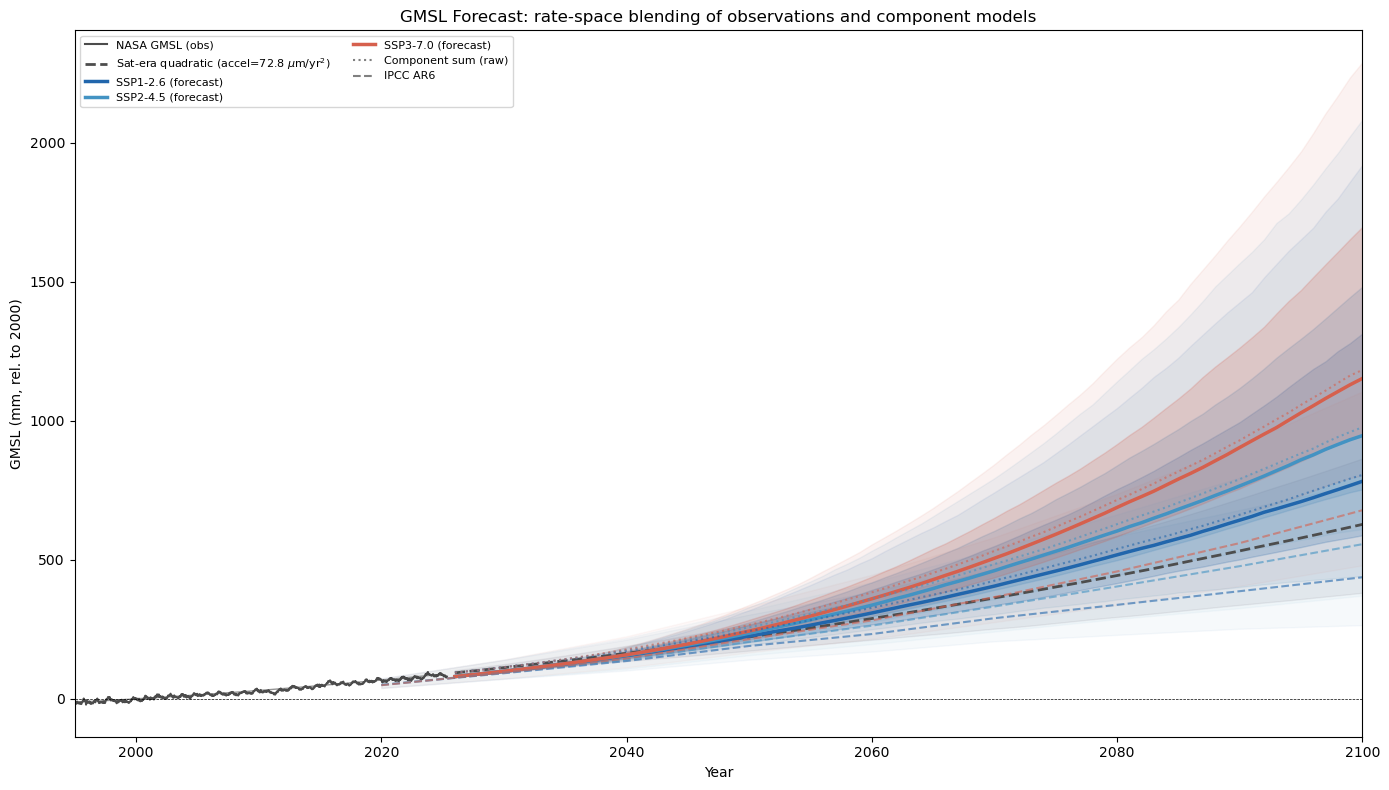

In [11]:
# ── Total GMSL forecast fan plot ──
fig, ax = plt.subplots(figsize=(14, 8))

# --- NASA GMSL observations ---
obs_mask = (nasa_time >= YEAR_START) & (nasa_time <= YEAR_END)
ax.plot(nasa_time[obs_mask], nasa_gmsl_rb[obs_mask] * M_TO_MM,
        'k-', lw=1.5, alpha=0.7, label='NASA GMSL (obs)')

# --- Satellite-era quadratic extrapolation ---
sq_obs_mask = (sq_time >= YEAR_START) & (sq_time <= nasa_time[-1])
ax.plot(sq_time[sq_obs_mask], sq_level_median[sq_obs_mask] * M_TO_MM,
        '-', color='0.3', lw=1, alpha=0.6)
sq_ext_mask = (sq_time >= nasa_time[-1]) & (sq_time <= YEAR_END)
ax.plot(sq_time[sq_ext_mask], sq_level_median[sq_ext_mask] * M_TO_MM,
        '--', color='0.3', lw=2,
        label=f'Sat-era quadratic (accel={sat_quad.accel*1e6:.1f} $\\mu$m/yr$^2$)')
if SHOW_UNCERT:
    ax.fill_between(sq_time[sq_ext_mask],
                    sq_level_p5[sq_ext_mask] * M_TO_MM,
                    sq_level_p95[sq_ext_mask] * M_TO_MM,
                    color='0.3', alpha=0.08)

# --- Blended forecast (per SSP) ---
for ssp in SSPS_SHOW:
    if ssp not in forecast:
        continue
    fc = forecast[ssp]
    fy = fc['years']
    fmask = fy <= YEAR_END
    color = SSP_COLORS.get(ssp, 'gray')
    ax.plot(fy[fmask], fc['median'][fmask] * M_TO_MM,
            color=color, lw=2.5, label=f'{ssp} (forecast)')
    if SHOW_UNCERT:
        ax.fill_between(fy[fmask],
                        fc['p17'][fmask] * M_TO_MM,
                        fc['p83'][fmask] * M_TO_MM,
                        color=color, alpha=0.20)
        ax.fill_between(fy[fmask],
                        fc['p5'][fmask] * M_TO_MM,
                        fc['p95'][fmask] * M_TO_MM,
                        color=color, alpha=0.08)

# --- Component sum (dotted, for reference) ---
proj_mask_plot = (proj_years >= T_ORIGIN) & (proj_years <= YEAR_END)
yr_plot = proj_years[proj_mask_plot]
for ssp in SSPS_SHOW:
    p = comp_projections[ssp]['Total_sum']
    color = SSP_COLORS.get(ssp, 'gray')
    ax.plot(yr_plot, p['median'][proj_mask_plot] * M_TO_MM,
            ':', color=color, lw=1.5, alpha=0.6)
ax.plot([], [], ':', color='0.5', lw=1.5, label='Component sum (raw)')

# --- IPCC AR6 total ---
for ssp in SSPS_SHOW:
    if ssp in ipcc_total:
        ie = ipcc_extract(ipcc_total[ssp])
        color = SSP_COLORS.get(ssp, 'gray')
        ipcc_mask = ie['years'] <= YEAR_END
        ax.plot(ie['years'][ipcc_mask], ie['q50'][ipcc_mask],
                color=color, lw=1.5, ls='--', alpha=0.6)
        if SHOW_UNCERT:
            ax.fill_between(ie['years'][ipcc_mask],
                            ie['q05'][ipcc_mask], ie['q95'][ipcc_mask],
                            color=color, alpha=0.04)
ax.plot([], [], ls='--', color='0.5', lw=1.5, label='IPCC AR6')

ax.set_xlabel('Year')
ax.set_ylabel('GMSL (mm, rel. to 2000)')
ax.set_title('GMSL Forecast: rate-space blending of observations and component models')
ax.set_xlim(YEAR_START, YEAR_END)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_forecast_total.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Per-Component Fan Plots

Individual component projections with IPCC AR6 counterparts for reference.
These are the raw component models (not blended); blending applies only to
the total.

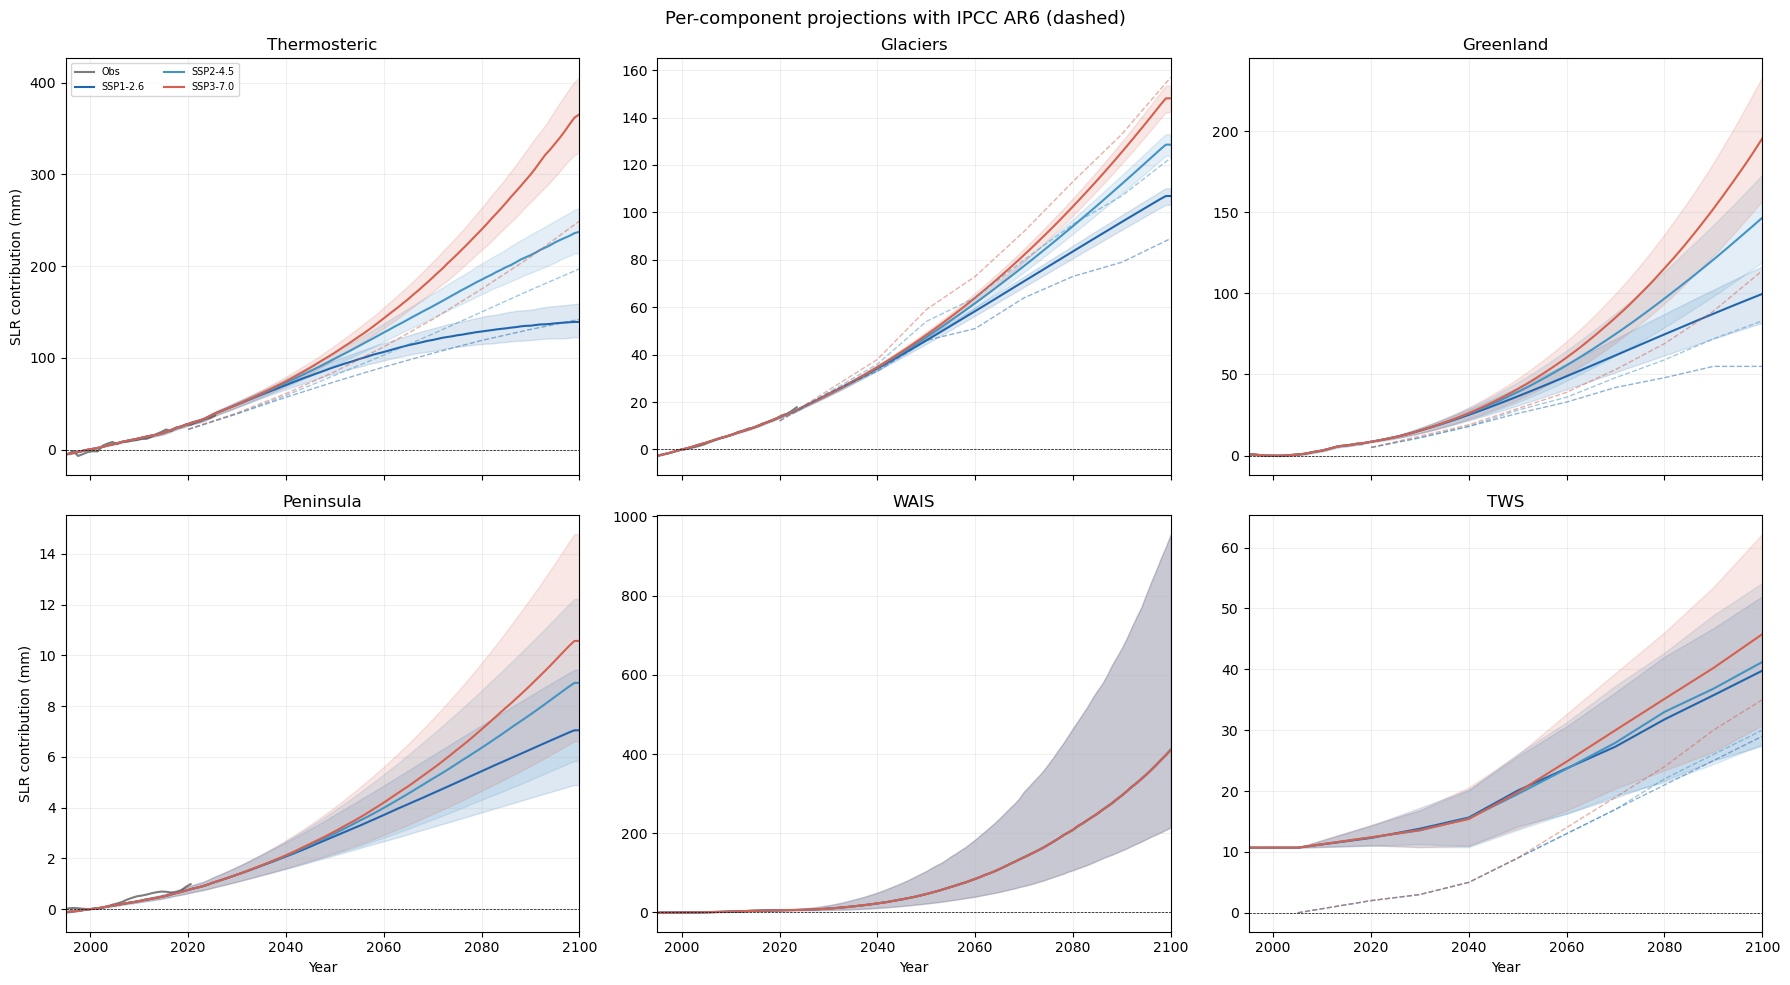

In [12]:
# ── Per-component fan plots with IPCC comparison ──
# Map our component labels to IPCC NetCDF component names
IPCC_COMP_MAP = {
    'Thermosteric': 'oceandynamics',
    'Glaciers': 'glaciers',
    'Greenland': 'GIS',
    'Peninsula': 'AIS',  # IPCC has combined AIS; we show it for Peninsula+WAIS
    'WAIS': 'AIS',
    'TWS': 'landwaterstorage',
}

# Load IPCC component data
ipcc_components = {}
for ssp, code in SSP_TO_CODE.items():
    ipcc_components[ssp] = {}
    for ipcc_key in set(IPCC_COMP_MAP.values()):
        data = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', code, ipcc_key)
        if data is not None:
            ipcc_components[ssp][ipcc_key] = data

# Load per-component observations from component_results.h5
comp_obs = {}
for comp_name in ['ocean', 'glacier', 'greenland', 'apeninsula', 'wais']:
    try:
        comp_obs[comp_name] = load_component(comp_name)
    except KeyError:
        pass

comp_order = ['Thermosteric', 'Glaciers', 'Greenland', 'Peninsula', 'WAIS', 'TWS']
hdf_key_map = {v: k for k, v in COMP_LABELS.items()}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()

proj_mask = (proj_years >= YEAR_START) & (proj_years <= YEAR_END)
yr_plot = proj_years[proj_mask]

for ax, cname in zip(axes, comp_order):
    hdf_key = hdf_key_map.get(cname)

    # Observations
    if hdf_key in comp_obs and 'observations' in comp_obs[hdf_key]:
        obs = comp_obs[hdf_key]['observations']
        if 'years' in obs:
            omask = (obs['years'] >= YEAR_START) & (obs['years'] <= YEAR_END)
            ax.plot(obs['years'][omask], obs['H_obs'][omask] * M_TO_MM,
                    color='#444444', lw=1.5, alpha=0.7, label='Obs')

    # Our projections (per SSP)
    for ssp in SSPS_SHOW:
        if cname not in comp_projections[ssp]:
            continue
        p = comp_projections[ssp][cname]
        color = SSP_COLORS.get(ssp, 'gray')
        ax.plot(yr_plot, p['median'][proj_mask] * M_TO_MM,
                color=color, lw=1.5, label=ssp)
        if SHOW_UNCERT:
            ax.fill_between(yr_plot,
                            p['p17'][proj_mask] * M_TO_MM,
                            p['p83'][proj_mask] * M_TO_MM,
                            color=color, alpha=0.15)

    # IPCC overlay (dashed)
    ipcc_key = IPCC_COMP_MAP.get(cname)
    if ipcc_key and ipcc_key != 'AIS':
        for ssp in SSPS_SHOW:
            if ssp in ipcc_components and ipcc_key in ipcc_components[ssp]:
                ie = ipcc_extract(ipcc_components[ssp][ipcc_key])
                color = SSP_COLORS.get(ssp, 'gray')
                ipcc_m = ie['years'] <= YEAR_END
                ax.plot(ie['years'][ipcc_m], ie['q50'][ipcc_m],
                        color=color, lw=1, ls='--', alpha=0.5)

    ax.set_title(cname)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_xlim(YEAR_START, YEAR_END)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('SLR contribution (mm)')
axes[3].set_ylabel('SLR contribution (mm)')
for ax in axes[3:]:
    ax.set_xlabel('Year')
axes[0].legend(fontsize=7, loc='upper left', ncol=2)

plt.suptitle('Per-component projections with IPCC AR6 (dashed)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_forecast_per_component.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Ridge Plots

Density evolution of the blended forecast at decadal intervals, compared
with the satellite-era quadratic extrapolation and IPCC AR6.

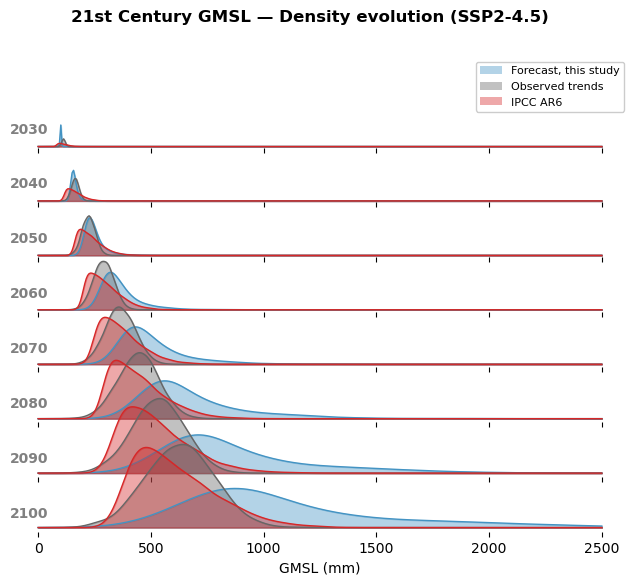

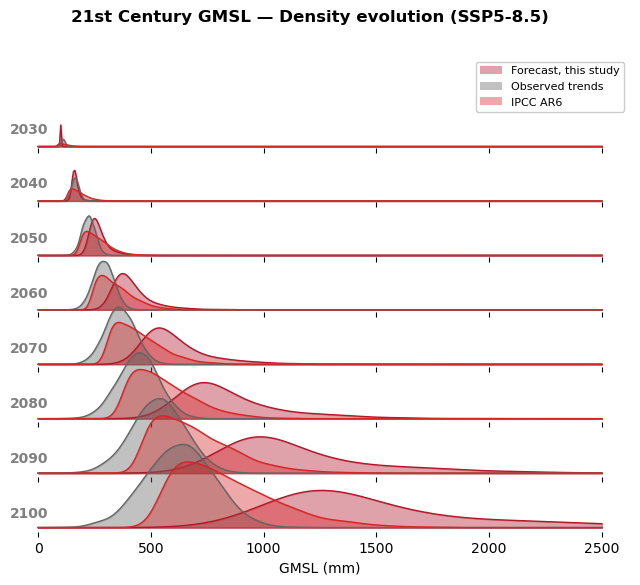

In [13]:
# ── Ridge plots: forecast density evolution by decade ──
# IPCC oversampled (10k) distributions loaded from precomputed file.
# Quadratic oversampled live (cheap).  KDE bw_factor=1.5.

N_RIDGE = 10_000
ridge_decades = [yr for yr in range(2030, 2101, 10)]

for ssp in ['SSP2-4.5', 'SSP5-8.5']:
    if ssp not in forecast:
        continue

    # Load precomputed IPCC ridge samples for this SSP
    try:
        ipcc_ridge_years, ipcc_ridge_mm = load_ipcc_ridge_samples('total', ssp)
    except KeyError:
        ipcc_ridge_years, ipcc_ridge_mm = None, None

    fc = forecast[ssp]
    samples_by_year = {}

    for yr in ridge_decades:
        # Blended forecast (2000 samples)
        idx_f = np.argmin(np.abs(fc['years'] - yr))
        fc_samples_mm = fc['samples'][:, idx_f] * M_TO_MM

        # Satellite quadratic (oversample from coefficient covariance)
        rng_sq_ridge = np.random.default_rng(seed=int(yr) + 1)
        sq_coeff_os = rng_sq_ridge.multivariate_normal(
            sat_quad.coefficients, sat_quad.cov_params, size=N_RIDGE)
        dt_yr = yr - sat_quad.t_start
        sq_vals = (sq_coeff_os[:, 0] + sq_coeff_os[:, 1] * dt_yr
                   + sq_coeff_os[:, 2] * dt_yr**2)
        sq_at_bl = (sq_coeff_os[:, 0]
                    + sq_coeff_os[:, 1] * (BASELINE_YEAR - sat_quad.t_start)
                    + sq_coeff_os[:, 2] * (BASELINE_YEAR - sat_quad.t_start)**2)
        sq_samples_mm = (sq_vals - sq_at_bl) * M_TO_MM

        entry = {}
        entry['Forecast'] = fc_samples_mm
        entry['Sat. quadratic'] = sq_samples_mm

        # IPCC: precomputed oversampled ridge data
        if ipcc_ridge_mm is not None:
            ipcc_yr_idx = np.argmin(np.abs(ipcc_ridge_years - yr))
            if np.abs(ipcc_ridge_years[ipcc_yr_idx] - yr) <= 5:
                entry['IPCC AR6'] = ipcc_ridge_mm[:, ipcc_yr_idx]

        samples_by_year[yr] = entry

    source_colors = {
        'Forecast': SSP_COLORS.get(ssp, 'gray'),
        'Sat. quadratic': '0.4',
        'IPCC AR6': 'tab:red',
    }

    plot_component_ridge(
        samples_by_year,
        component_name='21st Century GMSL',
        ssp_label=ssp,
        years=ridge_decades,
        source_labels=['Forecast', 'Sat. quadratic', 'IPCC AR6'],
        legend_labels=['Forecast, this study', 'Observed trends', 'IPCC AR6'],
        source_colors=source_colors,
        bw_factor=1.5,
        xlabel='GMSL (mm)',
        xlim=(0,2500),
        save_path=f'{FIG_DIR}/component_forecast_ridge_{ssp.replace(".", "").replace("-", "")}.png',
    )


In [14]:
# ── Summary table: forecast at milestone years ──
milestone_years = [2050, 2100]
if YEAR_END > 2100:
    milestone_years.append(2150)

rows = []
for ssp in SSPS_SHOW:
    if ssp not in forecast:
        continue
    fc = forecast[ssp]
    for yr in milestone_years:
        idx = np.argmin(np.abs(fc['years'] - yr))
        s = fc['samples'][:, idx] * M_TO_MM
        rows.append({
            'SSP': ssp, 'Year': yr,
            'Forecast (median [5, 95] mm)':
                f'{np.median(s):.0f} [{np.percentile(s, 5):.0f}, {np.percentile(s, 95):.0f}]',
        })

        # Quadratic for comparison
        idx_sq = np.argmin(np.abs(sq_time - yr))
        sq_s = sq_level_samples_rb[:, idx_sq] * M_TO_MM
        rows[-1]['Quadratic (median [5, 95] mm)'] = \
            f'{np.median(sq_s):.0f} [{np.percentile(sq_s, 5):.0f}, {np.percentile(sq_s, 95):.0f}]'

        # Component sum for comparison
        idx_p = np.argmin(np.abs(proj_years - yr))
        cs = comp_projections[ssp]['Total_sum']['samples'][:, idx_p] * M_TO_MM
        rows[-1]['Comp. sum (median [5, 95] mm)'] = \
            f'{np.median(cs):.0f} [{np.percentile(cs, 5):.0f}, {np.percentile(cs, 95):.0f}]'

        # IPCC
        if ssp in ipcc_total:
            ipcc_s = get_ipcc_stats({ssp: {'total': ipcc_total[ssp]}},
                                     ssp, 'total', year=yr)
            if ipcc_s is not None:
                rows[-1]['IPCC AR6 (median [5, 95] mm)'] = \
                    f'{ipcc_s[1]:.0f} [{ipcc_s[0]:.0f}, {ipcc_s[2]:.0f}]'

df_summary = pd.DataFrame(rows).set_index(['SSP', 'Year'])
display(df_summary)

Forecast (median [5, 95] mm) Quadratic (median [5, 95] mm)  \
SSP      Year                                                              
SSP1-2.6 2050               226 [193, 319]                223 [173, 270]   
         2100              782 [441, 1919]                627 [381, 864]   
SSP2-4.5 2050               236 [204, 330]                223 [173, 270]   
         2100              946 [610, 2082]                627 [381, 864]   
SSP3-7.0 2050               244 [212, 338]                223 [173, 270]   
         2100             1152 [803, 2288]                627 [381, 864]   

              Comp. sum (median [5, 95] mm) IPCC AR6 (median [5, 95] mm)  
SSP      Year                                                             
SSP1-2.6 2050                244 [203, 385]               190 [141, 303]  
         2100               805 [459, 1952]               437 [265, 775]  
SSP2-4.5 2050                257 [216, 401]               205 [157, 318]  
         2100               976 [629, 2127]               556 [371, 946]  
SSP3-7.0 2050                266 [226, 408]               215 [167, 332]  
         2100              1182 [827, 2349]              678 [480, 1105]